In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [2]:
!pip install -q SimpleITK pandas matplotlib numpy torch torchvision segmentation-models-pytorch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.5 MB/s eta 0:00:00


In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [20]:
%%writefile src/train.py
import os
import json
import argparse
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.dataset import SynthRAD2p5DDataset
from src.model import build_unetplusplus_resnet34
from src.losses import MaskedL1Loss


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader, desc="Training", leave=False):
        inputs = batch["input"].to(device)
        targets = batch["target"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            inputs = batch["input"].to(device)
            targets = batch["target"].to(device)
            masks = batch["mask"].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets, masks)

            running_loss += loss.item()

    return running_loss / len(loader)


def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

    df = pd.read_csv(args.patient_csv)

    with open(args.split_json, "r") as f:
        split = json.load(f)

    train_dataset = SynthRAD2p5DDataset(
        dataframe=df,
        patient_ids=split["train"],
        input_slices=args.input_slices,
        image_size=args.image_size,
        min_hu=args.min_hu,
        max_hu=args.max_hu,
        max_patients=args.max_train_patients
    )

    val_dataset = SynthRAD2p5DDataset(
        dataframe=df,
        patient_ids=split["val"],
        input_slices=args.input_slices,
        image_size=args.image_size,
        min_hu=args.min_hu,
        max_hu=args.max_hu,
        max_patients=args.max_val_patients
    )

    print("Train samples:", len(train_dataset))
    print("Val samples:", len(val_dataset))

    train_loader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=0
    )

    model = build_unetplusplus_resnet34(
        in_channels=args.input_slices,
        out_channels=1,
        encoder_weights="imagenet",
        dropout=args.dropout
    ).to(device)

    criterion = MaskedL1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.learning_rate)

    os.makedirs(args.checkpoint_dir, exist_ok=True)
    os.makedirs(args.log_dir, exist_ok=True)

    best_val_loss = float("inf")
    history = []

    for epoch in range(args.epochs):
        print(f"\nEpoch {epoch + 1}/{args.epochs}")

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        print(f"Train loss: {train_loss:.5f}")
        print(f"Val loss:   {val_loss:.5f}")

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        log_path = os.path.join(args.log_dir, f"training_log_fold{args.fold}.csv")
        pd.DataFrame(history).to_csv(log_path, index=False)

        last_ckpt_path = os.path.join(args.checkpoint_dir, f"last_fold{args.fold}.pth")
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "args": vars(args)
            },
            last_ckpt_path
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            best_ckpt_path = os.path.join(args.checkpoint_dir, f"best_fold{args.fold}.pth")
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "args": vars(args)
                },
                best_ckpt_path
            )

            print(f"Saved best checkpoint with val loss: {best_val_loss:.5f}")

    print("\nTraining finished.")
    print("Best validation loss:", best_val_loss)


if __name__ == "__main__":
    parser = argparse.ArgumentParser()

    parser.add_argument("--fold", type=int, default=0)
    parser.add_argument("--patient_csv", type=str, default="data/patient_list.csv")
    parser.add_argument("--split_json", type=str, default="splits/fold_0.json")

    parser.add_argument("--image_size", type=int, default=320)
    parser.add_argument("--input_slices", type=int, default=7)
    parser.add_argument("--min_hu", type=int, default=-1000)
    parser.add_argument("--max_hu", type=int, default=1600)

    parser.add_argument("--batch_size", type=int, default=2)
    parser.add_argument("--epochs", type=int, default=5)
    parser.add_argument("--learning_rate", type=float, default=1e-4)
    parser.add_argument("--dropout", type=float, default=0.2)

    parser.add_argument("--max_train_patients", type=int, default=10)
    parser.add_argument("--max_val_patients", type=int, default=3)

    parser.add_argument("--checkpoint_dir", type=str, default="checkpoints/test_training")
    parser.add_argument("--log_dir", type=str, default="results/metrics")

    args = parser.parse_args()


    args.split_json = f"splits/fold_{args.fold}.json"

    main(args)

Overwriting src/train.py


In [18]:
!touch /content/drive/MyDrive/CBCT_to_sCT_Project/src/__init__.py

In [21]:
%cd /content/drive/MyDrive/CBCT_to_sCT_Project

!touch src/__init__.py

!python -m src.train

/content/drive/MyDrive/CBCT_to_sCT_Project
Using device: cuda
GPU: Tesla T4
Train samples: 740
Val samples: 229
config.json: 100% 156/156 [00:00<00:00, 688kB/s]
model.safetensors: 100% 87.3M/87.3M [00:01<00:00, 51.2MB/s]

Epoch 1/5
Train loss: 0.11192
Val loss:   0.10574
Saved best checkpoint with val loss: 0.10574

Epoch 2/5
Train loss: 0.08576
Val loss:   0.08724
Saved best checkpoint with val loss: 0.08724

Epoch 3/5
Train loss: 0.07665
Val loss:   0.08761

Epoch 4/5
Train loss: 0.07462
Val loss:   0.09290

Epoch 5/5
Train loss: 0.06942
Val loss:   0.08964

Training finished.
Best validation loss: 0.08724341509134872


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log = pd.read_csv("results/metrics/training_log_fold0.csv")
log

,epoch,train_loss,val_loss
0,1,0.111921,0.105743
1,2,0.085758,0.087243
2,3,0.076651,0.087614
3,4,0.074624,0.092902
4,5,0.069422,0.089643


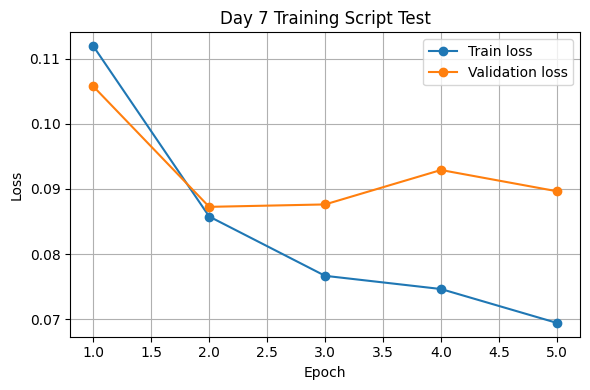

In [26]:
os.makedirs("results/figures/training", exist_ok=True)

plt.figure(figsize=(6, 4))
plt.plot(log["epoch"], log["train_loss"], marker="o", label="Train loss")
plt.plot(log["epoch"], log["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Day 7 Training Script Test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/figures/training/day7_training_script_loss.png", dpi=200)
plt.show()

In [30]:
%%writefile src/inference_preview.py
import os
import json
import argparse
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src.dataset import SynthRAD2p5DDataset
from src.model import build_unetplusplus_resnet34


def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    df = pd.read_csv(args.patient_csv)

    with open(args.split_json, "r") as f:
        split = json.load(f)

    val_dataset = SynthRAD2p5DDataset(
        dataframe=df,
        patient_ids=split["val"],
        input_slices=args.input_slices,
        image_size=args.image_size,
        min_hu=args.min_hu,
        max_hu=args.max_hu,
        max_patients=args.max_val_patients
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0
    )

    model = build_unetplusplus_resnet34(
        in_channels=args.input_slices,
        out_channels=1,
        encoder_weights=None,
        dropout=args.dropout
    ).to(device)

    checkpoint = torch.load(args.checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    batch = next(iter(val_loader))

    inputs = batch["input"].to(device)
    targets = batch["target"].to(device)

    with torch.no_grad():
        outputs = model(inputs)

    input_np = inputs[0].cpu().numpy()
    target_np = targets[0, 0].cpu().numpy()
    output_np = outputs[0, 0].cpu().numpy()

    center = input_np.shape[0] // 2

    os.makedirs(args.output_dir, exist_ok=True)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(input_np[center], cmap="gray", vmin=-1, vmax=1)
    plt.title("Input CBCT")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(target_np, cmap="gray", vmin=-1, vmax=1)
    plt.title("Target CT")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(output_np, cmap="gray", vmin=-1, vmax=1)
    plt.title("Predicted sCT")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(abs(output_np - target_np), cmap="hot")
    plt.title("Error Map")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(args.output_dir, "day7_prediction_preview.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved preview to:", save_path)


if __name__ == "__main__":
    parser = argparse.ArgumentParser()

    parser.add_argument("--patient_csv", type=str, default="data/patient_list.csv")
    parser.add_argument("--split_json", type=str, default="splits/fold_0.json")
    parser.add_argument("--checkpoint_path", type=str, required=True)

    parser.add_argument("--image_size", type=int, default=320)
    parser.add_argument("--input_slices", type=int, default=7)
    parser.add_argument("--min_hu", type=int, default=-1000)
    parser.add_argument("--max_hu", type=int, default=1600)
    parser.add_argument("--dropout", type=float, default=0.2)
    parser.add_argument("--max_val_patients", type=int, default=2)

    parser.add_argument("--output_dir", type=str, default="results/figures/predictions")

    args = parser.parse_args()
    main(args)

Writing src/inference_preview.py


In [31]:
!python -m src.inference_preview \
    --checkpoint_path checkpoints/test_training/best_fold0.pth \
    --output_dir results/figures/predictions

Using device: cuda
Figure(1600x400)
Saved preview to: results/figures/predictions/day7_prediction_preview.png
